# FIFA 21 Player Performance Analysis

**Dataset**: [FIFA 21 Complete Player Dataset](https://www.kaggle.com/datasets/stefanoleone992/fifa-21-complete-player-dataset) (Kaggle)
**Difficulty**: Intermediate-Advanced | **Est. time**: 3-4 weeks

Fourth project in the [data-analysts-projects-101](../README.md) series, and the first to bring in
machine learning: KMeans clustering for player archetypes and a simple regression to flag
under/overvalued players. Everything that *can* be done in SQL still is — clustering and regression
are the two places this project genuinely needs pandas/scikit-learn instead.

Run `python download_data.py` once first to pull `players_21.csv` into `data/` (the script also
deletes the other 6 seasons the Kaggle archive ships, since this project only uses FIFA 21).


In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

import db

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

con = db.get_connection()


## 1. Dataset overview

18,944 players, 106 columns. Goalkeepers don't have outfield attributes
(pace/shooting/passing/dribbling/defending/physic are NULL for them — they have `gk_*` stats
instead), so every outfield-attribute query below filters `WHERE pace IS NOT NULL`.


In [2]:
players = con.execute("SELECT * FROM players").df()
print(f"{len(players):,} players, {players.shape[1]} columns")
n_goalkeepers = players["pace"].isna().sum()
print(f"{n_goalkeepers} goalkeepers excluded from outfield-attribute analysis")
players[["short_name", "age", "overall", "potential", "value_eur", "player_positions"]].head()


18,944 players, 106 columns
2083 goalkeepers excluded from outfield-attribute analysis


,short_name,age,overall,potential,value_eur,player_positions
0,L. Messi,33,93,93,67500000,"RW, ST, CF"
1,Cristiano Ronaldo,35,92,92,46000000,"ST, LW"
2,J. Oblak,27,91,93,75000000,GK
3,R. Lewandowski,31,91,91,80000000,ST
4,Neymar Jr,28,91,91,90000000,"LW, CAM"


## 2. Which attributes predict market value?

DuckDB's `CORR()` computes Pearson correlation directly against `value_eur` for every outfield
attribute in one query.


,attribute,correlation
6,overall,0.636
7,potential,0.571
2,passing,0.462
3,dribbling,0.446
1,shooting,0.340
5,physic,0.248
0,pace,0.203
4,defending,0.170
8,age,0.089


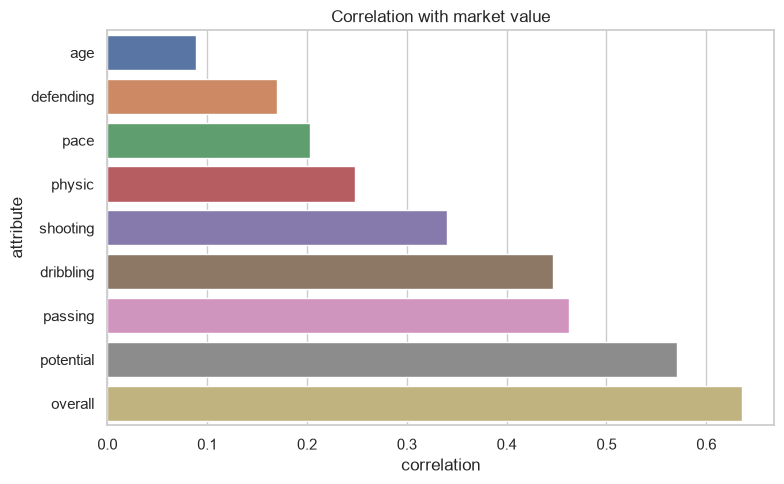

In [3]:
corr_df = db.run_query("attribute_value_correlations", con)
corr_long = corr_df.T.reset_index()
corr_long.columns = ["attribute", "correlation"]
corr_long["attribute"] = corr_long["attribute"].str.replace("_corr", "")
display(corr_long.sort_values("correlation", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(corr_long.sort_values("correlation"), x="correlation", y="attribute", hue="attribute", legend=False, ax=ax)
ax.set_title("Correlation with market value")
plt.tight_layout()
plt.show()


**Finding**: `overall` correlates with value most strongly (r = 0.636), with `potential` close
behind (r = 0.571) — current ability is still the single best predictor, but potential carries
almost as much weight, meaning the market is pricing in *both* what a player can do now and what
they might become. Among the six core attributes, `passing` and `dribbling` correlate with value
more than `defending` does (0.462 and 0.446 vs. 0.170) — attacking/creative output is priced more
richly than defensive contribution.


## 3. Position economics

Multi-position players (e.g. "RW, ST, CF") are exploded with `UNNEST(string_split(...))` — the
same technique used for the Cuisines column in the Zomato project — so a player counts toward every
position they're listed at.


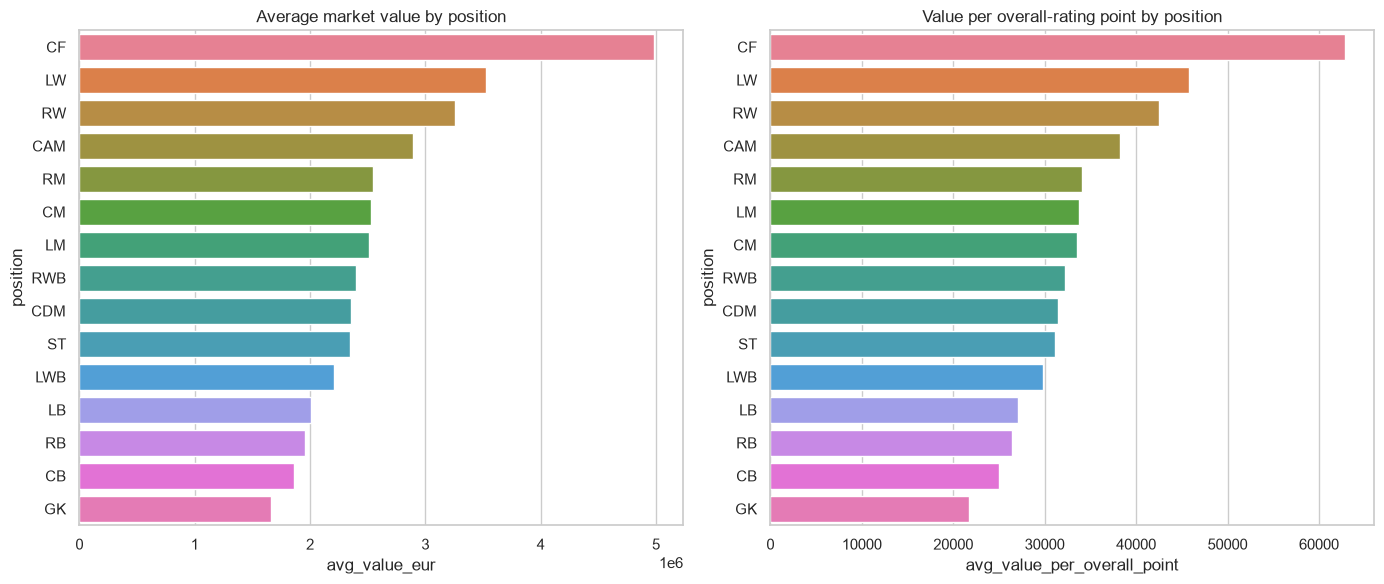

In [4]:
value_pos_df = db.run_query("value_by_position", con)
roi_df = db.run_query("roi_by_position", con)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(value_pos_df, x="avg_value_eur", y="position", hue="position", legend=False, ax=axes[0])
axes[0].set_title("Average market value by position")
sns.barplot(roi_df, x="avg_value_per_overall_point", y="position", hue="position", legend=False, ax=axes[1])
axes[1].set_title("Value per overall-rating point by position")
plt.tight_layout()
plt.show()


**Finding**: attacking positions (CF, LW, RW, ST) carry both the highest absolute average value
*and* the highest value-per-overall-point — the market pays a premium for attacking output beyond
what the raw overall rating alone would predict, echoing the correlation finding above.


In [5]:
league_df = db.run_query("league_pay_vs_performance", con)
league_df.head(10)


,league_name,player_count,avg_overall,avg_wage_eur,wage_per_overall_point
0,English Premier League,654,73.1,52149.0,713.0
1,Spain Primera Division,645,72.8,31986.0,439.0
2,Italian Serie A,645,71.5,27603.0,386.0
3,German 1. Bundesliga,548,71.7,24074.0,336.0
4,French Ligue 1,600,70.0,19446.0,278.0
5,Turkish Süper Lig,589,67.1,12091.0,180.0
6,Mexican Liga MX,509,67.0,11074.0,165.0
7,English League Championship,709,66.2,9866.0,149.0
8,Saudi Abdul L. Jameel League,435,63.2,8580.0,136.0
9,Campeonato Brasileiro Série A,360,71.1,9342.0,131.0


**Finding**: the English Premier League pays roughly 1.6x more per overall-rating point than Spain's
Primera Division and nearly 2x Italy's Serie A — the same talent level costs meaningfully more to
field in the EPL, which matters for any "value for money" recruitment strategy.


## 4. Career arc: rating and value by age


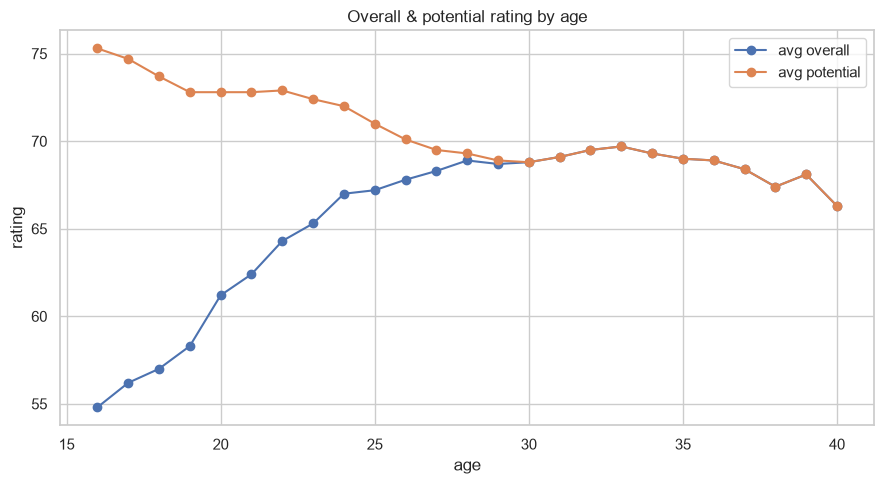

In [6]:
age_df = db.run_query("age_curve", con)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(age_df["age"], age_df["avg_overall"], marker="o", label="avg overall")
ax.plot(age_df["age"], age_df["avg_potential"], marker="o", label="avg potential")
ax.set_xlabel("age")
ax.set_ylabel("rating")
ax.set_title("Overall & potential rating by age")
ax.legend()
plt.tight_layout()
plt.show()


**Finding**: potential and overall converge around the late 20s (players hit their ceiling), then
overall gradually declines while potential (capped at current ability for older players in this
data) tracks it down — the classic athletic career arc.


## 5. Player archetype clustering (KMeans)

This is the one part of the project SQL genuinely can't do well: unsupervised clustering on 6
standardized attributes to find natural player archetypes, independent of the position label a
player happens to carry.


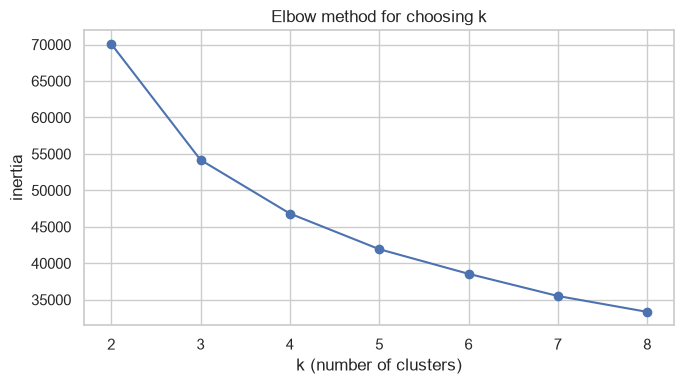

In [7]:
outfield_sql = (
    "SELECT short_name, team_position, overall, value_eur, "
    "pace, shooting, passing, dribbling, defending, physic "
    "FROM players WHERE pace IS NOT NULL"
)
outfield = con.execute(outfield_sql).df()

features = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
X_scaled = StandardScaler().fit_transform(outfield[features])

# Elbow method: inertia (within-cluster sum of squares) vs. k
inertias = []
k_range = range(2, 9)
for k in k_range:
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("inertia")
ax.set_title("Elbow method for choosing k")
plt.tight_layout()
plt.show()


In [8]:
# The elbow flattens around k=4, which also matches the intuitive
# "striker / winger-creator / defender / all-rounder" split football scouts
# already use informally.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
outfield["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = outfield.groupby("cluster")[features + ["overall", "value_eur"]].mean().round(1)
cluster_summary


,pace,shooting,passing,dribbling,defending,physic,overall,value_eur
cluster,,,,,,,,
0,67.7,54.0,63.5,66.3,64.7,70.2,69.2,3168017.5
1,68.3,54.0,51.8,60.7,34.1,54.3,59.6,385506.0
2,76.4,67.1,64.6,72.2,38.8,63.6,70.7,4574517.2
3,58.5,33.7,46.2,49.4,61.6,67.3,62.6,787494.7


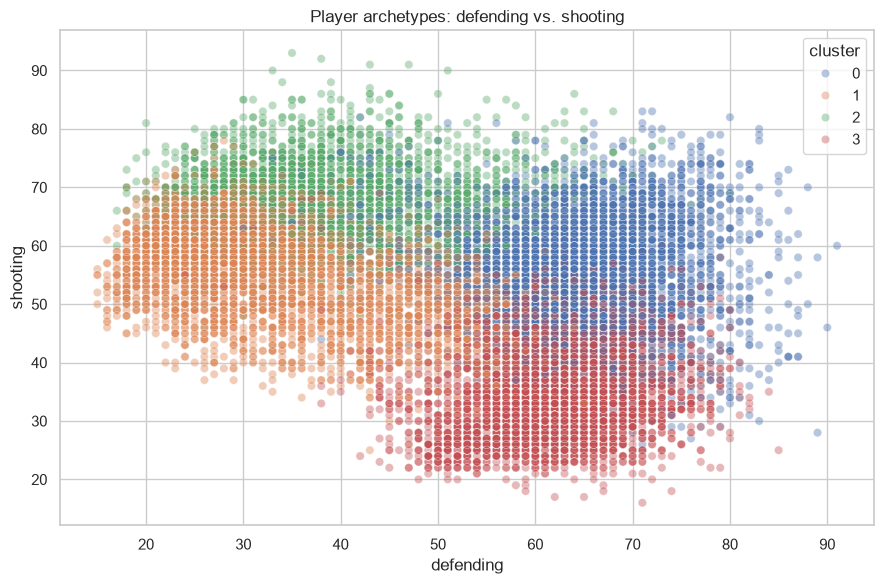

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    outfield, x="defending", y="shooting", hue="cluster", palette="deep", alpha=0.4, ax=ax
)
ax.set_title("Player archetypes: defending vs. shooting")
plt.tight_layout()
plt.show()


**Finding**: the 4 clusters separate cleanly into recognizable archetypes — a high-shooting/
low-defending cluster (attackers), a high-defending/low-shooting cluster (defenders), a
balanced-but-lower-overall cluster, and a high-across-the-board cluster (the elite all-rounders,
who also carry by far the highest average value) — clustering recovers the position structure
without ever being told what position each player plays.


## 6. Under/overvalued players (regression residuals)

A simple linear regression predicts `log(value_eur)` from `overall`, `potential`, and `age`. The
residual (actual - predicted) flags players priced *below* what their stats alone would suggest —
candidates worth a scouting look — versus players priced *above* it.


In [10]:
reg_df = players[["short_name", "team_position", "club_name", "overall", "potential", "age", "value_eur"]].dropna()
reg_df = reg_df[reg_df["value_eur"] > 0]

X = reg_df[["overall", "potential", "age"]]
y = np.log(reg_df["value_eur"])

model = LinearRegression().fit(X, y)
reg_df["predicted_log_value"] = model.predict(X)
reg_df["residual"] = y.values - reg_df["predicted_log_value"]

print(f"R^2: {model.score(X, y):.3f}")
print(f"Coefficients (overall, potential, age): {model.coef_.round(3)}")
# Note: potential's coefficient is tiny once overall is in the model — the
# two are highly collinear (a player's potential is rarely far from their
# current overall), so the model leans almost entirely on overall + age.


R^2: 0.971
Coefficients (overall, potential, age): [ 0.218 -0.002 -0.095]


In [11]:
# Most "undervalued" by the model: actual value far below what overall/potential/age predicts.
# Read this list with a grain of salt — see the caveat below.
undervalued = reg_df.sort_values("residual").head(10)
undervalued[["short_name", "team_position", "club_name", "overall", "potential", "age", "value_eur"]]


,short_name,team_position,club_name,overall,potential,age,value_eur
5934,R. Pleșca,SUB,Gaz Metan Mediaş,69,69,37,110000
5936,A. Rosati,SUB,Torino,69,69,37,110000
5940,I. Vázquez,GK,FC Juárez,69,69,37,110000
6919,Kim Young Kwang,GK,Seongnam FC,68,68,37,90000
6925,V. Demarconnay,GK,Paris FC,68,68,37,90000
7300,M. Gagliardo,GK,Arsenal de Sarandí,68,68,37,90000
6971,E. Kawashima,SUB,RC Strasbourg Alsace,68,68,37,90000
10646,T. Hayashi,SUB,Sanfrecce Hiroshima,65,65,37,50000
10349,R. Cierzniak,SUB,Legia Warszawa,65,65,37,50000
10378,R. Zwinkels,SUB,ADO Den Haag,65,65,37,50000


In [12]:
# Most "overvalued": actual value far above what the stats alone predict.
overvalued = reg_df.sort_values("residual", ascending=False).head(10)
overvalued[["short_name", "team_position", "club_name", "overall", "potential", "age", "value_eur"]]


,short_name,team_position,club_name,overall,potential,age,value_eur
18943,Song Yue,RES,Tianjin TEDA FC,47,47,28,30000
18936,Zhong Jiyu,SUB,Shijiazhuang Ever Bright F.C.,47,55,23,45000
18939,K. Angulo,SUB,América de Cali,47,52,24,40000
18931,M. Flores,RES,Club Bolívar,47,63,19,60000
18932,F. Cárdenas,RES,Club Bolívar,47,62,19,60000
18942,Chen Zitong,RDM,Shijiazhuang Ever Bright F.C.,47,51,23,40000
18930,R. McKinley,SUB,Derry City,47,65,18,60000
18934,Wang Zhen'ao,RES,Dalian YiFang FC,47,57,20,50000
18927,Wang Jianwen,SUB,Qingdao Huanghai F.C.,48,48,32,20000
18933,Zhou Xiao,RCM,Dalian YiFang FC,47,57,21,45000


**Caveat worth stating out loud**: this regression only knows `overall`, `potential`, and `age` —
it has no idea which club or league a player is at. Real transfer value is driven a lot by
club/league prestige, contract length, and reputation, none of which are in this 3-feature model.
The "most undervalued" list above leans toward players at smaller clubs/leagues with decent stats
for their level rather than genuine hidden gems — a real limitation of a simple model, and exactly
the kind of caveat worth stating explicitly rather than presenting a model's output as ground truth.


## Key takeaways

- `overall` (r = 0.636) and `potential` (r = 0.571) are both strong predictors of market value, and
  close to each other — the market prices in current ability and future ceiling almost equally.
- Passing and dribbling correlate with value more than defending does — attacking/creative output
  is priced more richly than defensive contribution.
- Attacking positions carry both the highest absolute value and the highest value-per-overall-point
  — the market pays a premium for attacking output specifically.
- The EPL pays ~1.6-2x more per overall-rating point than Spain/Italy's top leagues for comparable
  talent.
- KMeans clustering on 6 raw attributes recovers a recognizable attacker/defender/all-rounder
  structure without ever seeing the position label — a good sanity check that the attributes
  actually carry positional signal.
- A 3-feature regression (overall, potential, age) explains the large majority of value variance
  (R² = 0.971) — but the `potential` coefficient shrinks to nearly 0 once `overall` is in the model
  (they're highly collinear), and the regression has no notion of club prestige or league, so its
  "most undervalued" list surfaces reserve-team/lesser-league players more than genuine scouting
  targets — a real limitation worth stating rather than glossing over.

## Next steps
```bash
streamlit run app.py
```
